# PDE: some random PDE

$$
2\frac{\partial u}{\partial x} + 3\frac{\partial u}{\partial y} + 8u = 0
$$

Solution:
$$
u(x,y) = \sin\left(x - \frac{2}{3}y\right)e^{-\frac{8}{3}y}
$$

In [1]:
# imports
# numpy
import numpy as np

# torch
import torch
import torch.nn as nn
import torch.optim as optim

# plotting
import matplotlib.pyplot as plt
import seaborn as sns
#sns.set_theme(style="whitegrid")

In [2]:
# domain definition:
x_dom = torch.linspace(-5, 5, 100)
y_dom = torch.linspace(0, 5, 100)
xy_dom = torch.cartesian_prod(x_dom, y_dom)

# move data to gpu
xy_dom = xy_dom.to("cuda:0")
xy_dom.requires_grad = True # need to specify


In [3]:
class PINN(nn.Module):
    def __init__(self):
        super(PINN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 50),   # Input layer with 2 feature
            nn.Tanh(),
            nn.Linear(50, 50),  # Hidden layer
            nn.Tanh(),
            nn.Linear(50, 50),  # Hidden layer
            nn.Tanh(),
            nn.Linear(50, 1),    # Output layer for u(x,y)
        )

    def forward(self, X):
        return self.net(X)
    
    # Define the Poisson equation loss function
    def pde_loss(self, X):
        
        # compute estimation for function value
        u = self.forward(X)

        # get auxiliary tensor for gradient function
        vector = torch.ones_like(u)
        vector.to("cuda")

        # compute derivatives (gradient)
        u_X = torch.autograd.grad(u, X, grad_outputs=vector, create_graph=True)[0]
        u_x = u_X[:,0]
        u_y = u_X[:,1]
        
        # residue function
        f = (2*u_x + 3*u_y + 8*u)**2

        return torch.mean(f)

    def boundary_loss(self):

        x_sample = torch.linspace(-5, 5, 100)
        X = torch.zeros([x_sample.shape[0], 2])
        X[:,0] = x_sample
        X = X.detach().to("cuda")
        
        y = torch.sin(x_sample).to("cuda")
        
        u = self.forward(X)

        loss = (y.reshape(x_sample.shape[0], 1) - u)**2

        return loss

In [4]:
# Create PINN model and move to gpu
model = PINN().to(torch.device("cuda:0"))

# optimizer
optimizer = optim.Adam(params=model.parameters(), lr=5e-4)

# loss tracking
losses = []

# Training loop
epochs = 10000
for epoch in range(epochs):

    # zero grad
    optimizer.zero_grad()

    # extimation of output not needed
    # u_est = model(xy_dom)

    loss = torch.mean(model.pde_loss(xy_dom)) + torch.mean(model.boundary_loss())

    # Backpropagation
    loss.backward()
    losses.append(torch.log(loss).item())
    optimizer.step()               
    
    if epoch % 1000 == 0:
        print(f"Epoch [{epoch}/{epochs}], Loss: {loss.item()}")

Epoch [0/10000], Loss: 4.112170219421387
Epoch [1000/10000], Loss: 0.45749160647392273
Epoch [2000/10000], Loss: 0.4496978521347046
Epoch [3000/10000], Loss: 0.44810181856155396
Epoch [4000/10000], Loss: 0.44749727845191956
Epoch [5000/10000], Loss: 0.4471639394760132
Epoch [6000/10000], Loss: 0.45090460777282715
Epoch [7000/10000], Loss: 0.4467214047908783
Epoch [8000/10000], Loss: 0.44661134481430054
Epoch [9000/10000], Loss: 0.44750723242759705


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


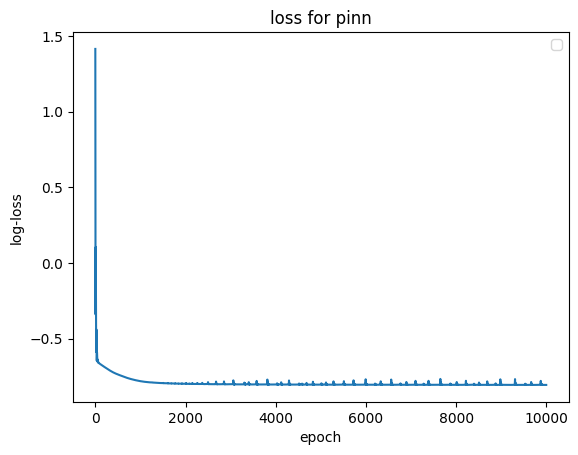

In [5]:
plt.figure()
plt.plot(losses)
plt.xlabel('epoch')
plt.ylabel('log-loss')
plt.title('loss for pinn')
plt.legend()
plt.show()

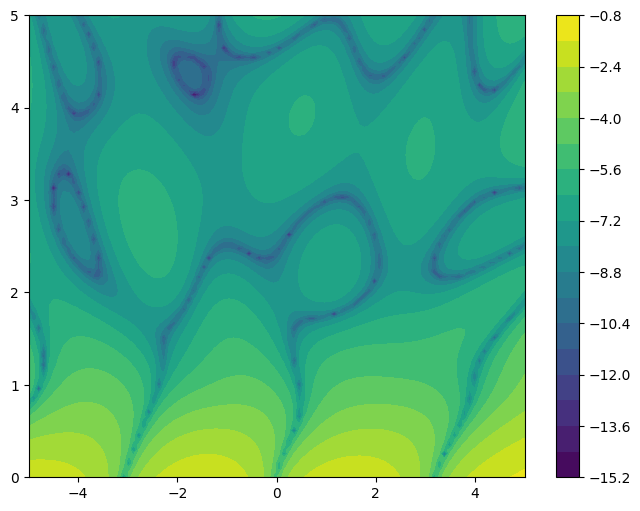

In [6]:
x = np.linspace(-5, 5, 100)
y = np.linspace(0, 5, 100)

X,Y = np.meshgrid(x, y)
data = np.vstack([X.ravel(), Y.ravel()])

pinn_model = model.to("cpu")

u_pinn = np.zeros_like(X)
u_pinn_log = np.zeros_like(X)

for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        u_pinn[i,j] = pinn_model(torch.Tensor([X[i,j],Y[i,j]]))
        u_pinn_log[i,j] = torch.log(torch.abs(pinn_model(torch.Tensor([X[i,j],Y[i,j]]))))

plt.figure(figsize=(8,6))
plt.contourf(X, Y, u_pinn_log.reshape(X.shape), levels=20)
plt.colorbar()
plt.show()

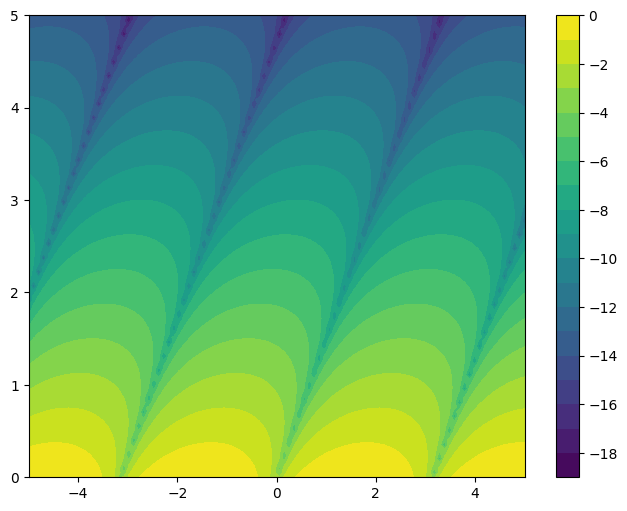

In [7]:
u_analytic = np.zeros_like(X)
u_analytic_log = np.zeros_like(X)


for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        u_analytic[i,j] = np.sin(X[i,j] - (2/3)*Y[i,j])*np.exp(-(8/3)*Y[i,j])
        u_analytic_log[i,j] = np.log(np.abs(np.sin(X[i,j] - (2/3)*Y[i,j])*np.exp(-(8/3)*Y[i,j])))

plt.figure(figsize=(8,6))
plt.contourf(X, Y, u_analytic_log.reshape(X.shape), levels=20)
plt.colorbar()
plt.show()

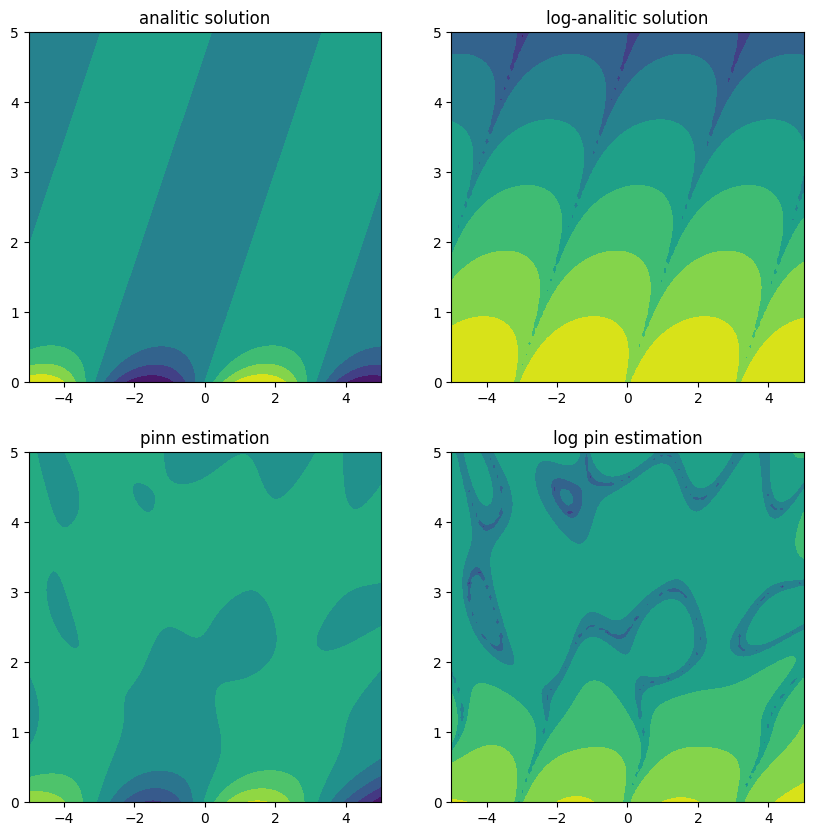

In [8]:
fig, axs = plt.subplots(2,2, figsize=(10,10))
axs[0,0].contourf(X,Y, u_analytic)
axs[0,1].contourf(X,Y, u_analytic_log)
axs[1,0].contourf(X,Y, u_pinn)
axs[1,1].contourf(X,Y, u_pinn_log)
axs[0,0].set_title("analitic solution")
axs[0,1].set_title("log-analitic solution")
axs[1,0].set_title("pinn estimation")
axs[1,1].set_title("log pin estimation")
fig.show()